## Mini-projekt (DP): „Co zmienia optymalną politykę i wartość startu?”

### Kontekst
W rozdziale 4 zrobiliśmy Dynamic Programming dla tablicowych MDP:
- mamy **model** środowiska w postaci `P[s][a] = [(p, s2, r, terminated), ...]`,
- umiemy liczyć:
  - `v_π` (policy evaluation),
  - poprawiać politykę (policy improvement),
  - znajdować optimum: `π*`, `v*` (policy iteration / value iteration).

W tym mini-projekcie wykonasz **krótkie badanie**: jak zmiana parametrów środowiska lub zadania wpływa na:
- `v*(start)` — wartość stanu startowego,
- oraz (opcjonalnie) kształt polityki `π*` (strzałki).

---

## Co to jest `v(start)` w skrócie (potem rozwinięte, jeśli ktoś potrzebuje)?
`v(start)` to wartość funkcji wartości w stanie startowym:

$
v(start) = V_\pi(s_{\text{start}})
$

czyli oczekiwana (zdyskontowana) suma nagród, gdy startujesz w `start` i działasz według polityki `π`.
W praktyce to jedna liczba odpowiadająca na pytanie:

> **„Jak dobry jest ten sposób działania, jeśli startuję z typowego stanu startowego?”**

---

## Zadanie (obowiązkowe)
Twoim celem jest wykonać **eksperyment + analizę** (badanie). Zrób to w krokach:

### Krok 1 — wybierz środowisko
Wybierz jedno (albo zrób oba jako bonus):
- FrozenLake (`P_fl_det` lub `P_fl_slip`) — epizodyczne (Start - Goal, pamiętacie?:) ),
- Gridworld (`P_gw` lub większy Gridworld, jeśli jest w notebooku) — continuing (jak wyżej :) ).

Ustal `start_state` (zwykle `0`).
 v(start) to jedna liczba, która pozwala porównywać eksperymenty.
Musisz więc wskazać z jakiego stanu startujesz.

### Krok 2 — policz optimum (punkt odniesienia)
Policz `π*` i `v*` metodą DP:
- `value_iteration(...)` lub `policy_iteration(...)`.

Zapisz `v*(start)`.

### Krok 3 — wybierz 2 pytania badawcze i wykonaj eksperymenty
Wybierz **dwa** pytania z listy poniżej i wykonaj pomiary (sweep parametrów).

### Krok 4 — zrób wykresy
Dla każdego pytania przygotuj co najmniej **1 wykres**.
Minimalnie: wykres parametru (X) → `v*(start)` (Y).

### Krok 5 — opisz wnioski (krótko, ale konkretnie)
Napisz 4–8 zdań:
- co zmieniałeś,
- co zmierzyłeś,
- co wyszło i dlaczego (intuicja + odniesienie do definicji Bellmana).

---

## Pytania badawcze (wybierz 2)

### Pytanie A — wpływ `γ` (gamma)
**Hipoteza do sprawdzenia:** większe `γ` zwiększa znaczenie przyszłości i zmienia `v*(start)` oraz czasem politykę.

Zrób sweep po `γ`, np. `[0.8, 0.9, 0.95, 0.99]`.
Dla każdego `γ` policz `v*(start)`.

**Wykres:** `γ` vs `v*(start)`.

---

### Pytanie B — deterministyczne vs slippery (FrozenLake)
**Hipoteza do sprawdzenia:** stochastyczność (`slippery=True`) obniża `v*(start)` i może zmienić `π*`.

Porównaj:
- `P_fl_det` vs `P_fl_slip` (dla tego samego `γ`).

**Wykres:** dwa punkty/kolumny (det vs slippery) dla `v*(start)` (albo dwa przebiegi vs γ).

---

### Pytanie C — wpływ kar/nagród w Gridworld
**Hipoteza do sprawdzenia:** większe kary za ścianę lub mniejsze nagrody teleportów zmieniają `v*` i „kierunek” polityki.

Zrób sweep po jednym parametrze środowiska (jeśli masz builder świata):
- `wall_penalty ∈ {-1, -2, -5}`,
- lub nagrody teleportów (np. zmniejsz/zwieksz).

**Wykres:** parametr vs `v*(start)`.

---

### Pytanie D — PI vs VI jako metody numeryczne
**Hipoteza do sprawdzenia:** PI ma mniej iteracji „zewnętrznych”, a VI robi więcej prostych backupów.

Zmierz czas działania (np. `time.time()`) dla PI i VI na tym samym środowisku.

**Wykres:** słupki czasu (PI vs VI) lub liczba iteracji (jeśli zapisujesz liczbę iteracji).

> Uwaga: polityki mogą się różnić w stanach z remisami, ale `v*` powinno być takie samo (w granicach numeryki).

---

## Co oznacza dokładnie `v(start)` i jak policzyć (powtórzenie powtórzenia :) )?

`v(start)` to **wartość stanu startowego** (czyli wartość funkcji wartości w stanie, od którego zwykle zaczynamy):

$
v(start) = V_\pi(s_{\text{start}})
$

### Definicja (intuicja)
Jeśli zaczynamy w stanie `start` i dalej postępujemy zgodnie z polityką \(\pi\),
to `v(start)` jest **oczekiwaną (zdyskontowaną) sumą przyszłych nagród**:

$
V_\pi(s_{\text{start}})=\mathbb{E}_\pi\left[\sum_{t=0}^{\infty}\gamma^t R_{t+1}\ \middle|\ S_0=s_{\text{start}}\right]
$

Czyli to jedna liczba, która odpowiada na pytanie:

> **„Jak dobry jest ten sposób działania (polityka), jeśli zaczynam od stanu startowego?”**

---

## Jak interpretować `v(start)` w naszych środowiskach?

### 1) FrozenLake (epizodyczne, nagroda na końcu)
W FrozenLake nagroda jest zwykle:
- `+1` za wejście na pole `G` (goal),
- `0` w pozostałych przypadkach,
- epizod kończy się na `H` (hole) lub `G`.

W takim układzie `v(start)` można interpretować jako:

> **zdyskontowaną “szansę sukcesu”** (dotarcia do celu), uwzględniając ryzyko i γ.

- `slippery=True` obniża `v(start)`, bo ruch jest mniej kontrolowalny → częściej kończysz w dziurze.
- większe `γ` sprawia, że bardziej „opłaca się” dążyć do odległego celu (mniej karzesz opóźnienie).

### 2) Gridworld (ciągłe / continuing)
W Gridworld nagrody mogą pochodzić z:
- teleportów/specjalnych pól (dodatnie nagrody),
- kar za wyjście poza planszę (np. -1),
- ewentualnie kosztu kroku (jeśli go dodasz).

Wtedy `v(start)` mówi:

> **jakiego długoterminowego zysku (lub kosztu) oczekujemy**, startując z lewego górnego rogu (lub innego startu), jeśli działamy wg danej polityki.

---

## Dlaczego `v(start)` jest przydatne?

To **jedna liczba** (prosty wskaźnik), dzięki której można:
- porównywać różne polityki (losowa vs optymalna),
- porównywać różne ustawienia środowiska (np. `slippery`),
- porównywać różne parametry (`γ`, kary, nagrody teleportów),
- robić wykresy typu: *parametr → jakość zachowania*.

W praktyce to DP-odpowiednik „średniego returnu” znanego z RL,
tylko że tu liczymy go z modelu (bez próbkowania epizodów).

---

## Jak policzyć `v(start)` w notebooku?

Zakładamy, że masz:
- `v` jako wektor wartości stanów (np. wynik policy/value iteration albo policy evaluation),
- `start_state` (u nas zwykle `0`).

Wtedy (po dowolnej metodzie ___ iteration):

```python
v_start = float(v[start_state])
print("v(start) =", v_start)
```

## Przykład rozgrzewkowy (template): wpływ γ na `v*(start)` w FrozenLake

### W tym przykładzie **Krok 1 i Krok 2 są już wykonane**:
- środowisko jest wybrane (`P_fl_slip`),
- w każdej iteracji liczymy optimum (`π*`, `v*`) metodą `value_iteration`.

Poniższy kod jest **wzorcem**, który skopiujesz później dla Gridworld.
Przyjmujemy konwencję `start_state = 0` (lewy górny róg / pole `S`).


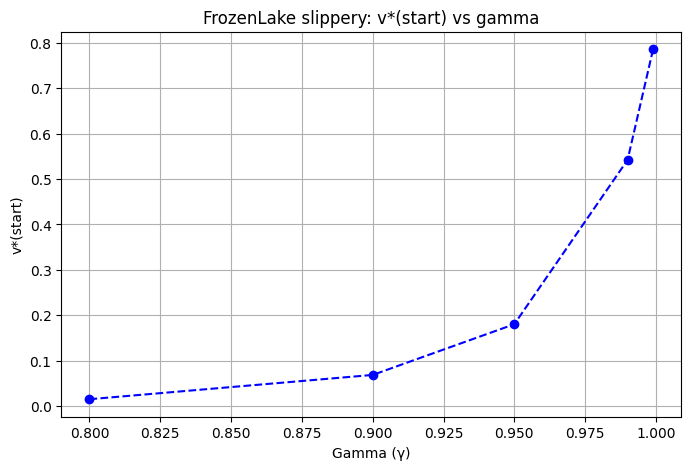

Wyniki (gamma, v_start):
[(0.8, 0.015434338412935969), (0.9, 0.06889090447458573), (0.95, 0.18047157761948457), (0.99, 0.5420259308172166), (0.999, 0.7855332550140832)]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

# 1. Definicja funkcji Value Iteration
def value_iteration(P, gamma=0.9, theta=1e-10):
    n_states = len(P)
    n_actions = len(P[0])
    V = np.zeros(n_states)
    
    while True:
        delta = 0
        for s in range(n_states):
            v_old = V[s]
            # Obliczanie Q(s, a) dla każdego działania
            q_values = []
            for a in range(n_actions):
                q_a = 0
                for prob, next_state, reward, terminated in P[s][a]:
                    q_a += prob * (reward + gamma * V[next_state])
                q_values.append(q_a)
            
            V[s] = max(q_values)
            delta = max(delta, abs(v_old - V[s]))
            
        if delta < theta:
            break
            
    # Wyznaczenie optymalnej polityki pi*
    pi = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = []
        for a in range(n_actions):
            q_a = 0
            for prob, next_state, reward, terminated in P[s][a]:
                q_a += prob * (reward + gamma * V[next_state])
            q_values.append(q_a)
        pi[s] = np.argmax(q_values)
        
    return pi, V

# 2. Przygotowanie środowiska (modelu P)
env = gym.make("FrozenLake-v1", is_slippery=True)
P_fl_slip = env.unwrapped.P

# 3. Twój oryginalny kod eksperymentu
gammas = [0.8, 0.9, 0.95, 0.99, 0.999]
vstarts = []
start_state = 0

for g in gammas:
    pi_star, v_star = value_iteration(P_fl_slip, gamma=g, theta=1e-10)
    vstarts.append(float(v_star[start_state]))

# Wykres
plt.figure(figsize=(8, 5))
plt.plot(gammas, vstarts, marker='o', linestyle='--', color='b')
plt.xlabel("Gamma (γ)")
plt.ylabel("v*(start)")
plt.title("FrozenLake slippery: v*(start) vs gamma")
plt.grid(True)
plt.show()

print("Wyniki (gamma, v_start):")
print(list(zip(gammas, vstarts)))

## Przykładowa ścieżka rozwiązania pytania badawczego A (porównawcze): Jak `γ` działa w zadaniu epizodycznym vs continuing?
W ramach projektu można po prostu ją przeprowadzić wg opisu (prawie gotowe :) )
tylko trzeba przeprowadzić te eksperymety, zrozumieć i opisać swoimi słowami.

### Cel
Porównaj wpływ parametru dyskontowania `γ` na `v*(start)` w dwóch różnych typach zadań:

- **FrozenLake** (epizodyczne): nagroda jest na końcu epizodu (dotarcie do `G`)
- **Gridworld** (continuing): proces trwa bez końca (zbieramy nagrody w nieskończonym horyzoncie)

### Dlaczego to jest ciekawe?
`γ` kontroluje, jak mocno cenisz przyszłość.  
W epizodycznym zadaniu jego wpływ wygląda inaczej niż w continuing, bo:
- w FrozenLake nagroda zwykle pojawia się po kilku krokach (krótka trajektoria),
- w Gridworld liczy się „długoterminowe zachowanie” w nieskończonym horyzoncie.

### Co mierzymy
Dla każdej wartości `γ` liczymy:
- `v*(start)` w FrozenLake (det lub slippery),
- `v*(start)` w Gridworld.

Następnie robimy wykres:
- oś X: `γ`,
- oś Y: `v*(start)`.

### Zakres γ (proponowany)
Użyj np. listy:
`gammas = [0.8, 0.9, 0.95, 0.99]`

> Uwaga: w continuing zadaniach DP zakładamy `γ < 1`, bo wtedy operator Bellmana jest kontrakcją
> i wartości są dobrze określone.

---

## Przykład (wzór implementacyjny) — wykonany dla FrozenLake

Poniższa komórka pokazuje, jak zrobić sweep po `γ` dla jednego środowiska.  
W kolejnym kroku zastosujesz ten sam wzór dla Gridworld.


In [5]:
import gymnasium as gym

# Model deterministyczny (bez ślizgania)
env_det = gym.make("FrozenLake-v1", is_slippery=False)
P_fl_det = env_det.unwrapped.P

# Model ze ślizganiem (slippery - może się przydać do wcześniejszego zadania)
env_slip = gym.make("FrozenLake-v1", is_slippery=True)
P_fl_slip = env_slip.unwrapped.P

In [6]:
import numpy as np

def value_iteration(P, gamma=0.9, theta=1e-10):
    n_states = len(P)
    n_actions = len(P[0])
    V = np.zeros(n_states)
    
    while True:
        delta = 0
        for s in range(n_states):
            v_old = V[s]
            # Liczymy Q(s, a) dla wszystkich akcji
            q_values = []
            for a in range(n_actions):
                q_a = 0
                for prob, next_state, reward, terminated in P[s][a]:
                    q_a += prob * (reward + gamma * V[next_state])
                q_values.append(q_a)
            
            V[s] = max(q_values)
            delta = max(delta, abs(v_old - V[s]))
            
        if delta < theta:
            break
            
    # Wyznaczenie optymalnej polityki
    pi = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = [sum(p * (r + gamma * V[s2]) for p, s2, r, _ in P[s][a]) 
                    for a in range(n_actions)]
        pi[s] = np.argmax(q_values)
        
    return pi, V

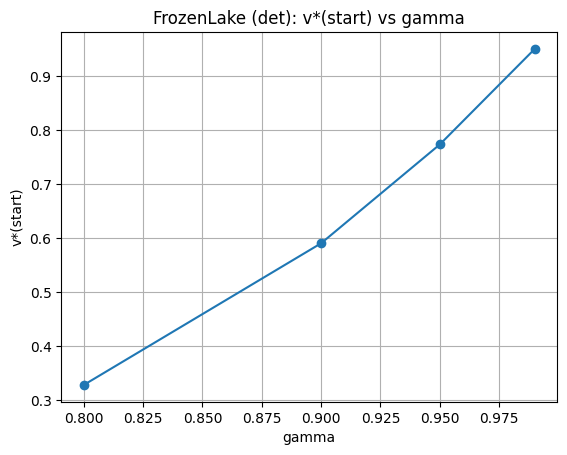

[(0.8, 0.32768000000000014), (0.9, 0.5904900000000002), (0.95, 0.7737809374999999), (0.99, 0.9509900498999999)]


In [7]:
import matplotlib.pyplot as plt

gammas = [0.8, 0.9, 0.95, 0.99]
start_state = 0

vstarts_fl = []
for g in gammas:
    pi_star, v_star = value_iteration(P_fl_det, gamma=g, theta=1e-10)
    vstarts_fl.append(float(v_star[start_state]))

plt.figure()
plt.plot(gammas, vstarts_fl, marker='o')
plt.xlabel("gamma")
plt.ylabel("v*(start)")
plt.title("FrozenLake (det): v*(start) vs gamma")
plt.grid(True)
plt.show()

print(list(zip(gammas, vstarts_fl)))


## Twoje zadanie: zrób to samo dla Gridworld i porównaj

1) Powtórz sweep po `γ` dla **Gridworld** (ten sam `gammas`, ten sam `start_state=0`).
2) Zrób jeden wspólny wykres z dwiema krzywymi:
   - FrozenLake (det lub slippery),
   - Gridworld.

### Kod (szablon — uzupełnij tylko brakujące fragmenty)


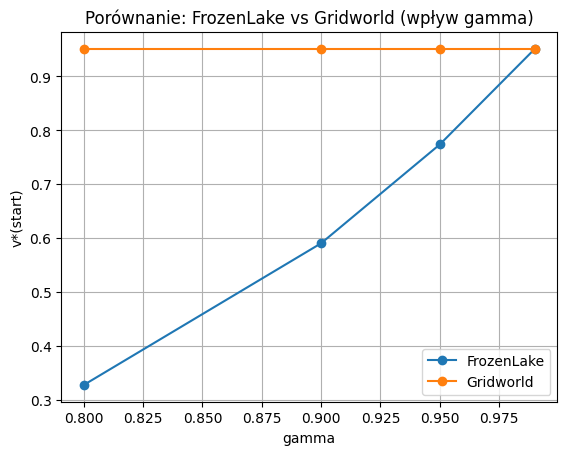

FrozenLake: [(0.8, 0.32768000000000014), (0.9, 0.5904900000000002), (0.95, 0.7737809374999999), (0.99, 0.9509900498999999)]
Gridworld: [(0.8, 0.9509900498999999), (0.9, 0.9509900498999999), (0.95, 0.9509900498999999), (0.99, 0.9509900498999999)]


In [8]:
vstarts_gw = []
for g in gammas:
    # TODO: policz v* w Gridworld (value_iteration albo policy_iteration)
    # Wykonaj algorytm i wstaw do vstarts_gw - można skorzystać z wcześniejszych implementacji/wywołań - wyżej jest przykład
    vstarts_gw.append(float(v_star[start_state]))

plt.figure()
plt.plot(gammas, vstarts_fl, marker='o', label="FrozenLake")
plt.plot(gammas, vstarts_gw, marker='o', label="Gridworld")
plt.xlabel("gamma")
plt.ylabel("v*(start)")
plt.title("Porównanie: FrozenLake vs Gridworld (wpływ gamma)")
plt.grid(True)
plt.legend()
plt.show()

print("FrozenLake:", list(zip(gammas, vstarts_fl)))
print("Gridworld:", list(zip(gammas, vstarts_gw)))


## Pytania do analizy (napisz 4–8 zdań)

1) Jak zmienia się `v*(start)` wraz z `γ` w FrozenLake?  
   (Podpowiedź: w det często widać zależność ~ `γ^L`, gdzie L to długość najlepszej ścieżki.)

2) Jak wygląda wpływ `γ` w Gridworld? Czy jest „silniejszy” / „słabszy” niż w FrozenLake?

3) Dlaczego te dwa światy zachowują się inaczej?  
   Użyj pojęć: epizodyczne vs continuing, horyzont czasowy, nagroda na końcu vs nagrody w nieskończonym czasie.

4) Czy przy bardzo dużym `γ` wartości w Gridworld robią się bardzo duże?  
   Jeśli tak, co to mówi o naturze continuing zadań i roli dyskontowania?


### Odpowiedzi
* W środowisku FrozenLake  rośnie wraz ze wzrostem  zgodnie z zależnością , gdzie  to liczba kroków do celu. Wynika to z faktu, że wyższa wartość  sprawia, iż nagroda otrzymana na końcu epizodu jest mniej "karana" za opóźnienie w czasie.
* W Gridworld wpływ  jest zazwyczaj silniejszy niż w FrozenLake, ponieważ mamy do czynienia z zadaniem kontynuowanym (continuing), w którym nagrody zbierane są w nieskończonym horyzoncie czasowym.
* Przy bardzo dużych wartościach  (bliskich 1) wartości w Gridworld mogą stać się ekstremalnie wysokie, co jest efektem sumowania nagród otrzymywanych bez końca.
* Zastosowanie dyskontowania  jest niezbędne w zadaniach typu continuing, aby zapewnić zbieżność algorytmu i zagwarantować, że oczekiwana suma nagród pozostanie liczbą skończoną.